# Classification with Census Income dataset

In [3]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import glob
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import scipy.stats as stats
from sklearn import preprocessing
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
data = pd.read_csv('census_income/adult.data',
                    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num',
                           'marital-status', 'occupation', 'relationship', 'race', 'sex',
                           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
                           'income'],
                    index_col=False)
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
data_test = pd.read_csv('census_income/adult.test',
                    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num',
                           'marital-status', 'occupation', 'relationship', 'race', 'sex',
                           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
                           'income'],
                    index_col=False)
data_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,|1x3 Cross validator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K.
2,38,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
3,28,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K.
4,44,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16277,39,Private,215419.0,Bachelors,13.0,Divorced,Prof-specialty,Not-in-family,White,Female,0.0,0.0,36.0,United-States,<=50K.
16278,64,?,321403.0,HS-grad,9.0,Widowed,?,Other-relative,Black,Male,0.0,0.0,40.0,United-States,<=50K.
16279,38,Private,374983.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K.
16280,44,Private,83891.0,Bachelors,13.0,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455.0,0.0,40.0,United-States,<=50K.


In [7]:
data.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Data preparation

In [9]:
def data_preparing(df, cols):
  # getting rid of whitespace in object columns
  df[cols] = df[cols].apply(lambda x: x.astype(str).str.strip())
  # replacing ? with nan
  df = df.replace({'?': np.nan})

  print(
    f"The dataset contains {df.shape[0]} samples and "
    f"{len(df.columns)} columns"
  )

  return df

In [10]:
data_prepared = data_preparing(data, ['age', 'workclass', 'education',
                                      'marital-status', 'occupation', 'relationship', 'race', 'sex',
                                      'native-country', 'income'])

data_prepared['age'] = data_prepared['age'].astype(int)
data_prepared.head(10)

The dataset contains 32561 samples and 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [11]:
# Count missing values in each column
missing_values = data_prepared.isnull().sum()
print(missing_values)

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64


In [12]:
missing_by_class = data_prepared.groupby('income').apply(lambda group: group.isnull().sum())

# Add total instances per class for reference
missing_by_class['Total Instances'] = data_prepared.groupby('income').size()

# Calculate percentage of missing values for each feature
missing_percentage = missing_by_class.div(missing_by_class['Total Instances'], axis=0) * 100

# Display the result
print("Missing Values Count by Class:")
print(missing_by_class)

print("\nPercentage of Missing Values by Class:")
print(missing_percentage)

Missing Values Count by Class:
        age  workclass  fnlwgt  education  education-num  marital-status  \
income                                                                     
<=50K     0       1645       0          0              0               0   
>50K      0        191       0          0              0               0   

        occupation  relationship  race  sex  capital-gain  capital-loss  \
income                                                                    
<=50K         1652             0     0    0             0             0   
>50K           191             0     0    0             0             0   

        hours-per-week  native-country  income  Total Instances  
income                                                           
<=50K                0             437       0            24720  
>50K                 0             146       0             7841  

Percentage of Missing Values by Class:
        age  workclass  fnlwgt  education  education-num  m

In [13]:
data_prepared

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [14]:
# Fill missing values in categorical columns with mode for each class

data_prepared['workclass'] = data_prepared.groupby('income')['workclass'].transform(lambda x: x.fillna(x.mode()[0]))
data_prepared['occupation'] = data_prepared.groupby('income')['occupation'].transform(lambda x: x.fillna(x.mode()[0]))
data_prepared['native-country'] = data_prepared.groupby('income')['native-country'].transform(lambda x: x.fillna(x.mode()[0]))

In [15]:
data_prepared = data_prepared.drop_duplicates()

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'fnlwgt'}>],
       [<Axes: title={'center': 'education-num'}>,
        <Axes: title={'center': 'capital-gain'}>],
       [<Axes: title={'center': 'capital-loss'}>,
        <Axes: title={'center': 'hours-per-week'}>]], dtype=object)

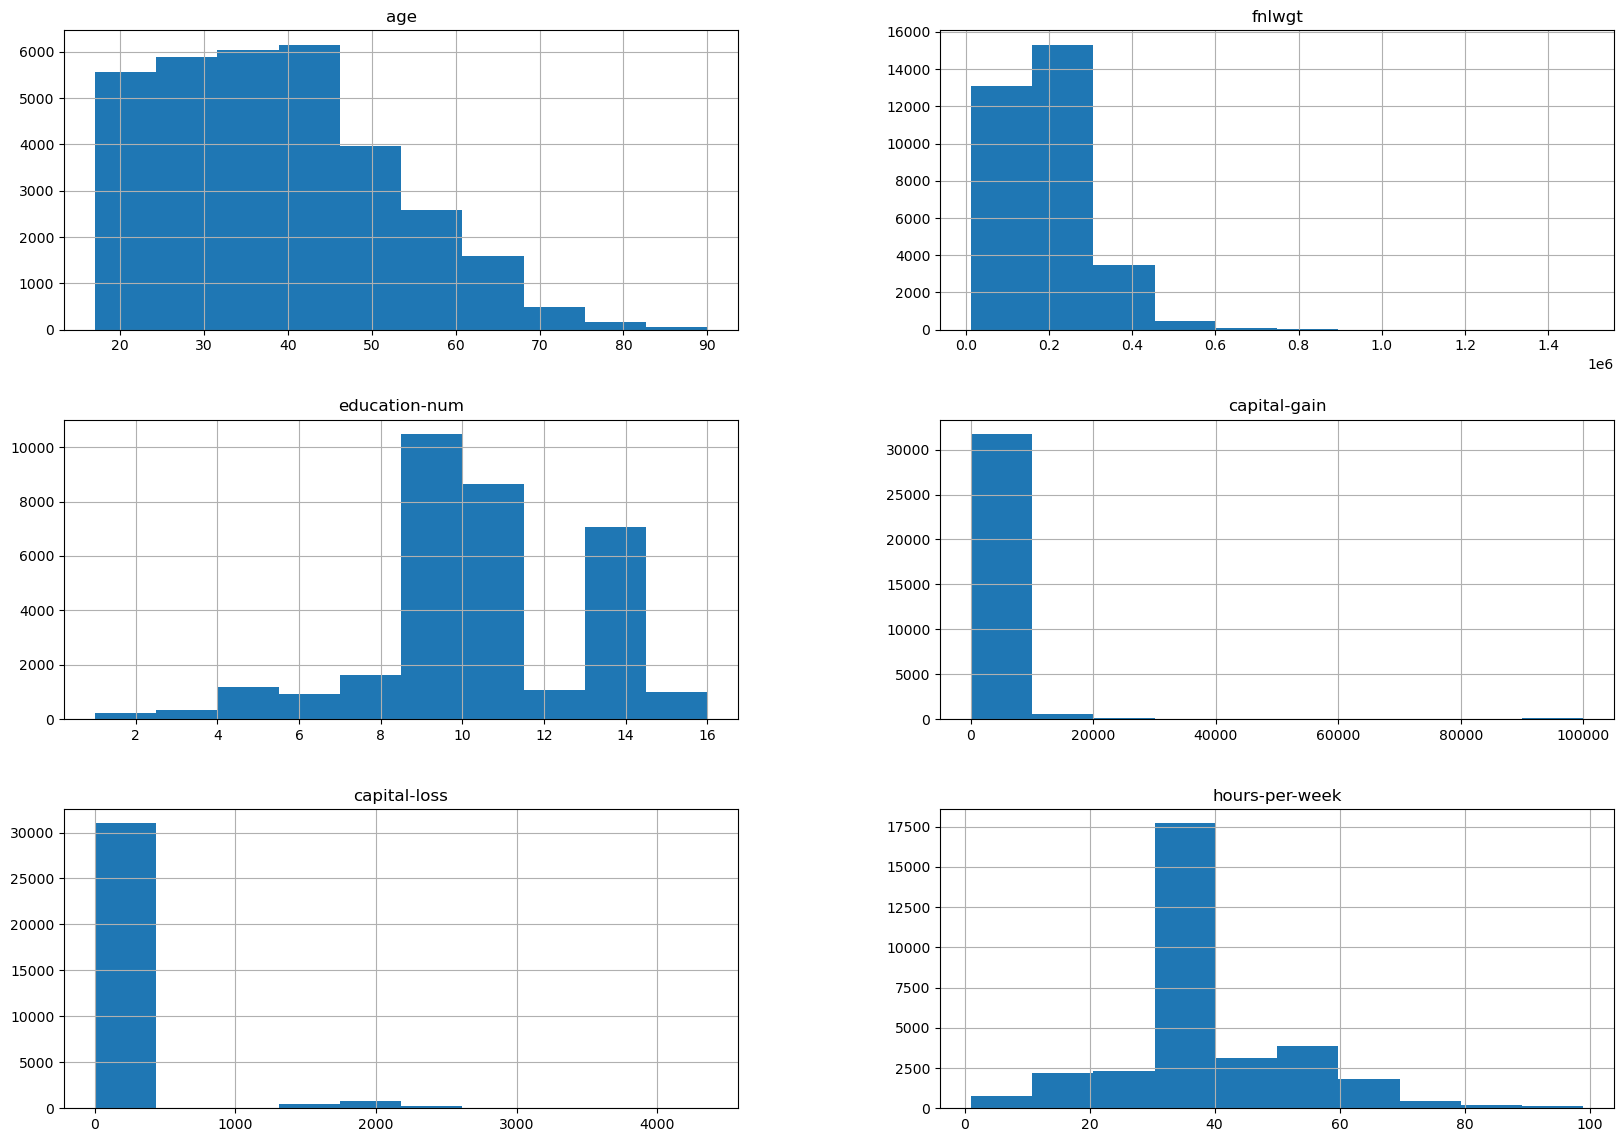

In [16]:
data_prepared.hist(figsize=(20, 14))

In [17]:
# Creating a Treemap for 'Race'
race = data_prepared['race'].value_counts()

plt.style.use('default')
plt.figure(figsize=(12, 12))
squarify.plot(sizes=race.values, label=race.index, value=race.values)
plt.title('Race distribution', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.show()

NameError: name 'squarify' is not defined

<Figure size 1200x1200 with 0 Axes>

In [ ]:
# Creating a countplot of income across age
plt.style.use('default')
plt.figure(figsize=(20, 7))
sns.countplot(data=data_prepared, x='age', hue='income')
plt.title('Distribution of capital-gain across age')
plt.xlabel('Age')
plt.ylabel('Number of people')
plt.legend(loc=1, prop={'size': 15})
plt.show()

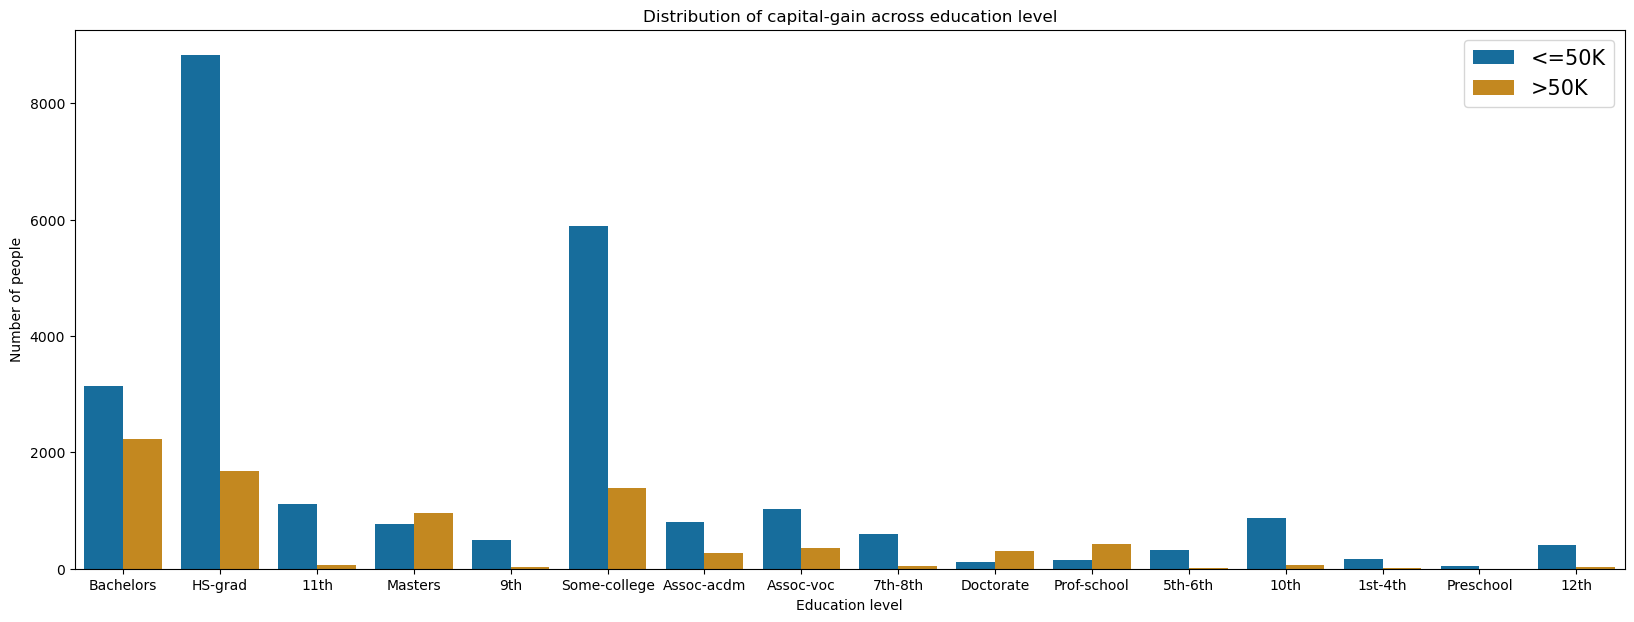

In [18]:
# Creating a countplot of income across education

plt.figure(figsize=(20, 7))
sns.countplot(data=data_prepared, x='education', hue='income', palette='colorblind')
plt.title('Distribution of capital-gain across education level')
plt.xlabel('Education level')
plt.ylabel('Number of people')
plt.legend(loc=1, prop={'size': 15})
plt.show()

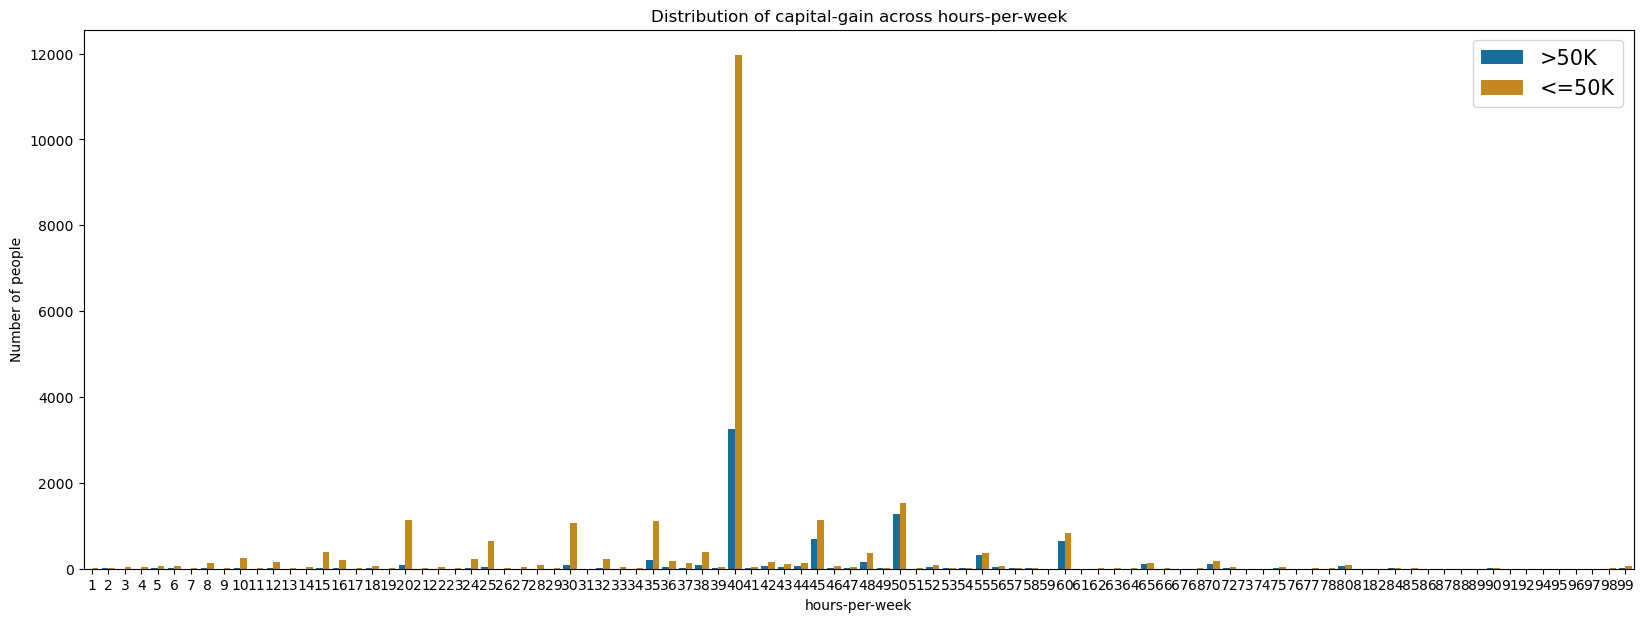

In [19]:
# Creating a countplot of income across hours-per-week

plt.figure(figsize=(20, 7))
sns.countplot(data=data_prepared, x='hours-per-week', hue='income', palette='colorblind')
plt.title('Distribution of capital-gain across hours-per-week')
plt.xlabel('hours-per-week')
plt.ylabel('Number of people')
plt.legend(loc=1, prop={'size': 15})
plt.show()

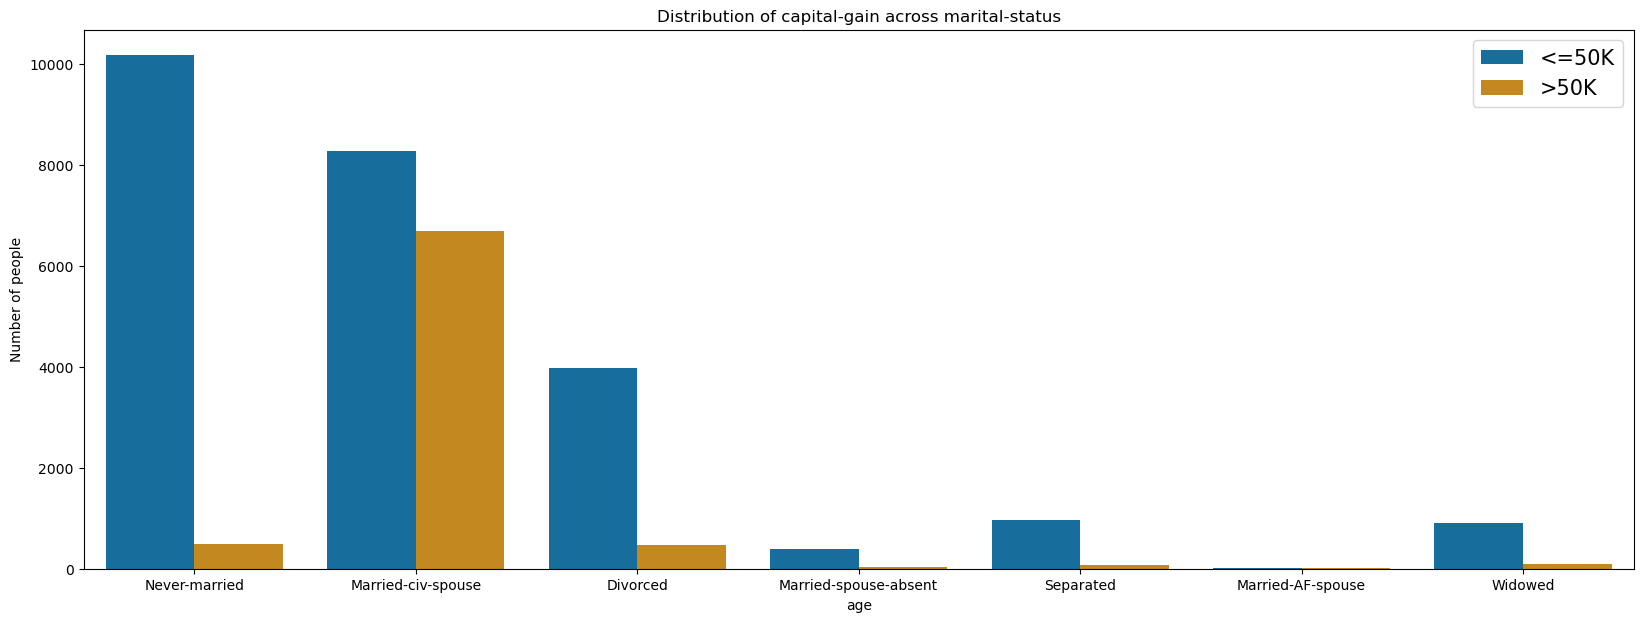

In [20]:
# Creating a countplot of income across marital-status

plt.figure(figsize=(20, 7))
sns.countplot(data=data_prepared, x='marital-status', hue='income', palette='colorblind')
plt.title('Distribution of capital-gain across marital-status')
plt.xlabel('age')
plt.ylabel('Number of people')
plt.legend(loc=1, prop={'size': 15})
plt.show()

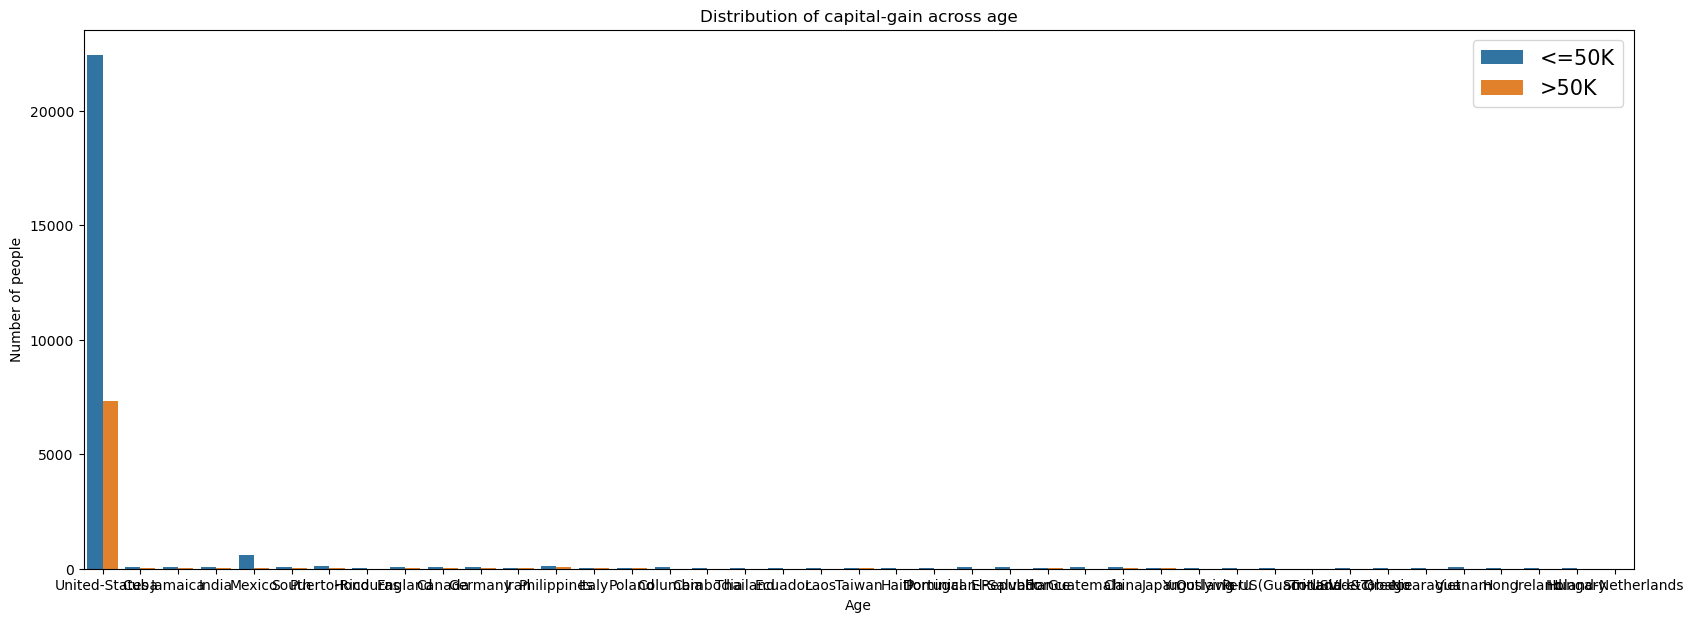

In [21]:
# Creating a countplot of income across age
plt.style.use('default')
plt.figure(figsize=(20, 7))
sns.countplot(data=data_prepared, x='native-country', hue='income')
plt.title('Distribution of capital-gain across age')
plt.xlabel('Age')
plt.ylabel('Number of people')
plt.legend(loc=1, prop={'size': 15})
plt.show()

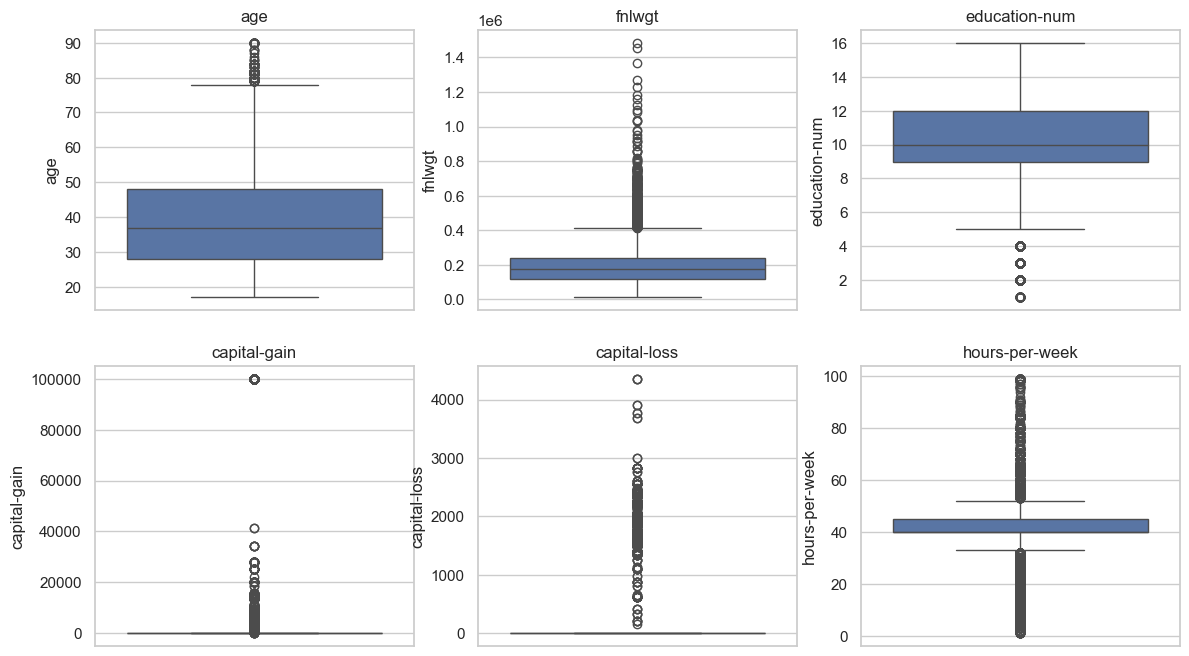

In [22]:
# Select only numeric columns for boxplot
numeric_columns = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# Create a figure with multiple subplots
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

# Plot a boxplot for each numeric column
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)  # Adjust the layout (2 rows, 3 columns)
    sns.boxplot(y=data_prepared[column])
    plt.title(column)

In [23]:
# handling the outliers (quantile < 0.24 and quantile > 75)

def handle_outliers(df, column):
    data_cleaned = df.copy()

    Q1 = data_cleaned[column].quantile(0.25)
    Q3 = data_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data_cleaned[(data_cleaned[column] >= lower_bound) & (data_cleaned[column] <= upper_bound)]

In [24]:
for column in numeric_columns:
    data_cleaned = handle_outliers(data_prepared, column)


print(f"Data shape before removing outliers: {data_prepared.shape}")
print(f"Data shape after removing outliers: {data_cleaned.shape}")

Data shape before removing outliers: (32536, 15)
Data shape after removing outliers: (23534, 15)


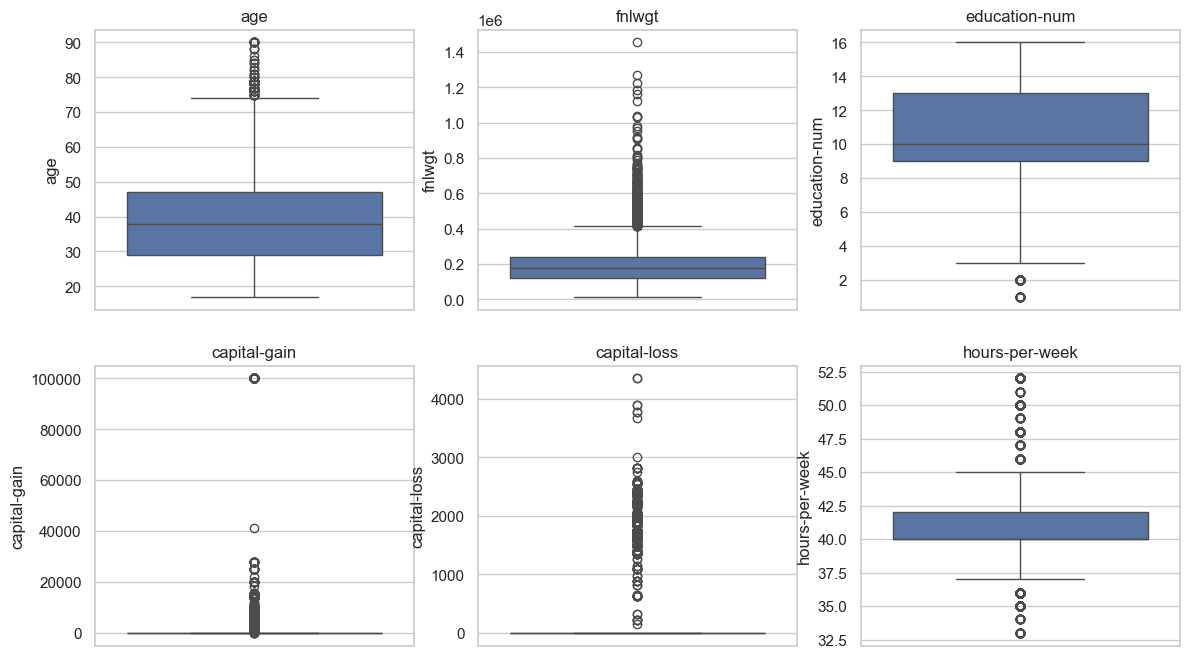

In [25]:
# Create a figure with multiple subplots
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

# Plot a boxplot for each numeric column
for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)  # Adjust the layout (2 rows, 3 columns)
    sns.boxplot(y=data_cleaned[column])
    plt.title(column)

## Preparation for Classification

In [26]:
#data_cleaned = data_prepared.copy()

In [27]:
# encoding non-numeric variables

data_encoded = data_cleaned.copy()
le = preprocessing.LabelEncoder()

for column in data_encoded.select_dtypes(include=['object']).columns:
  data_encoded[column] = le.fit_transform(data_encoded[column])

data_encoded

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0
5,37,3,284582,12,14,2,3,5,4,0,0,0,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,3,310152,15,10,4,10,1,4,1,0,0,40,38,0
32556,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,0
32557,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,1
32558,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,0


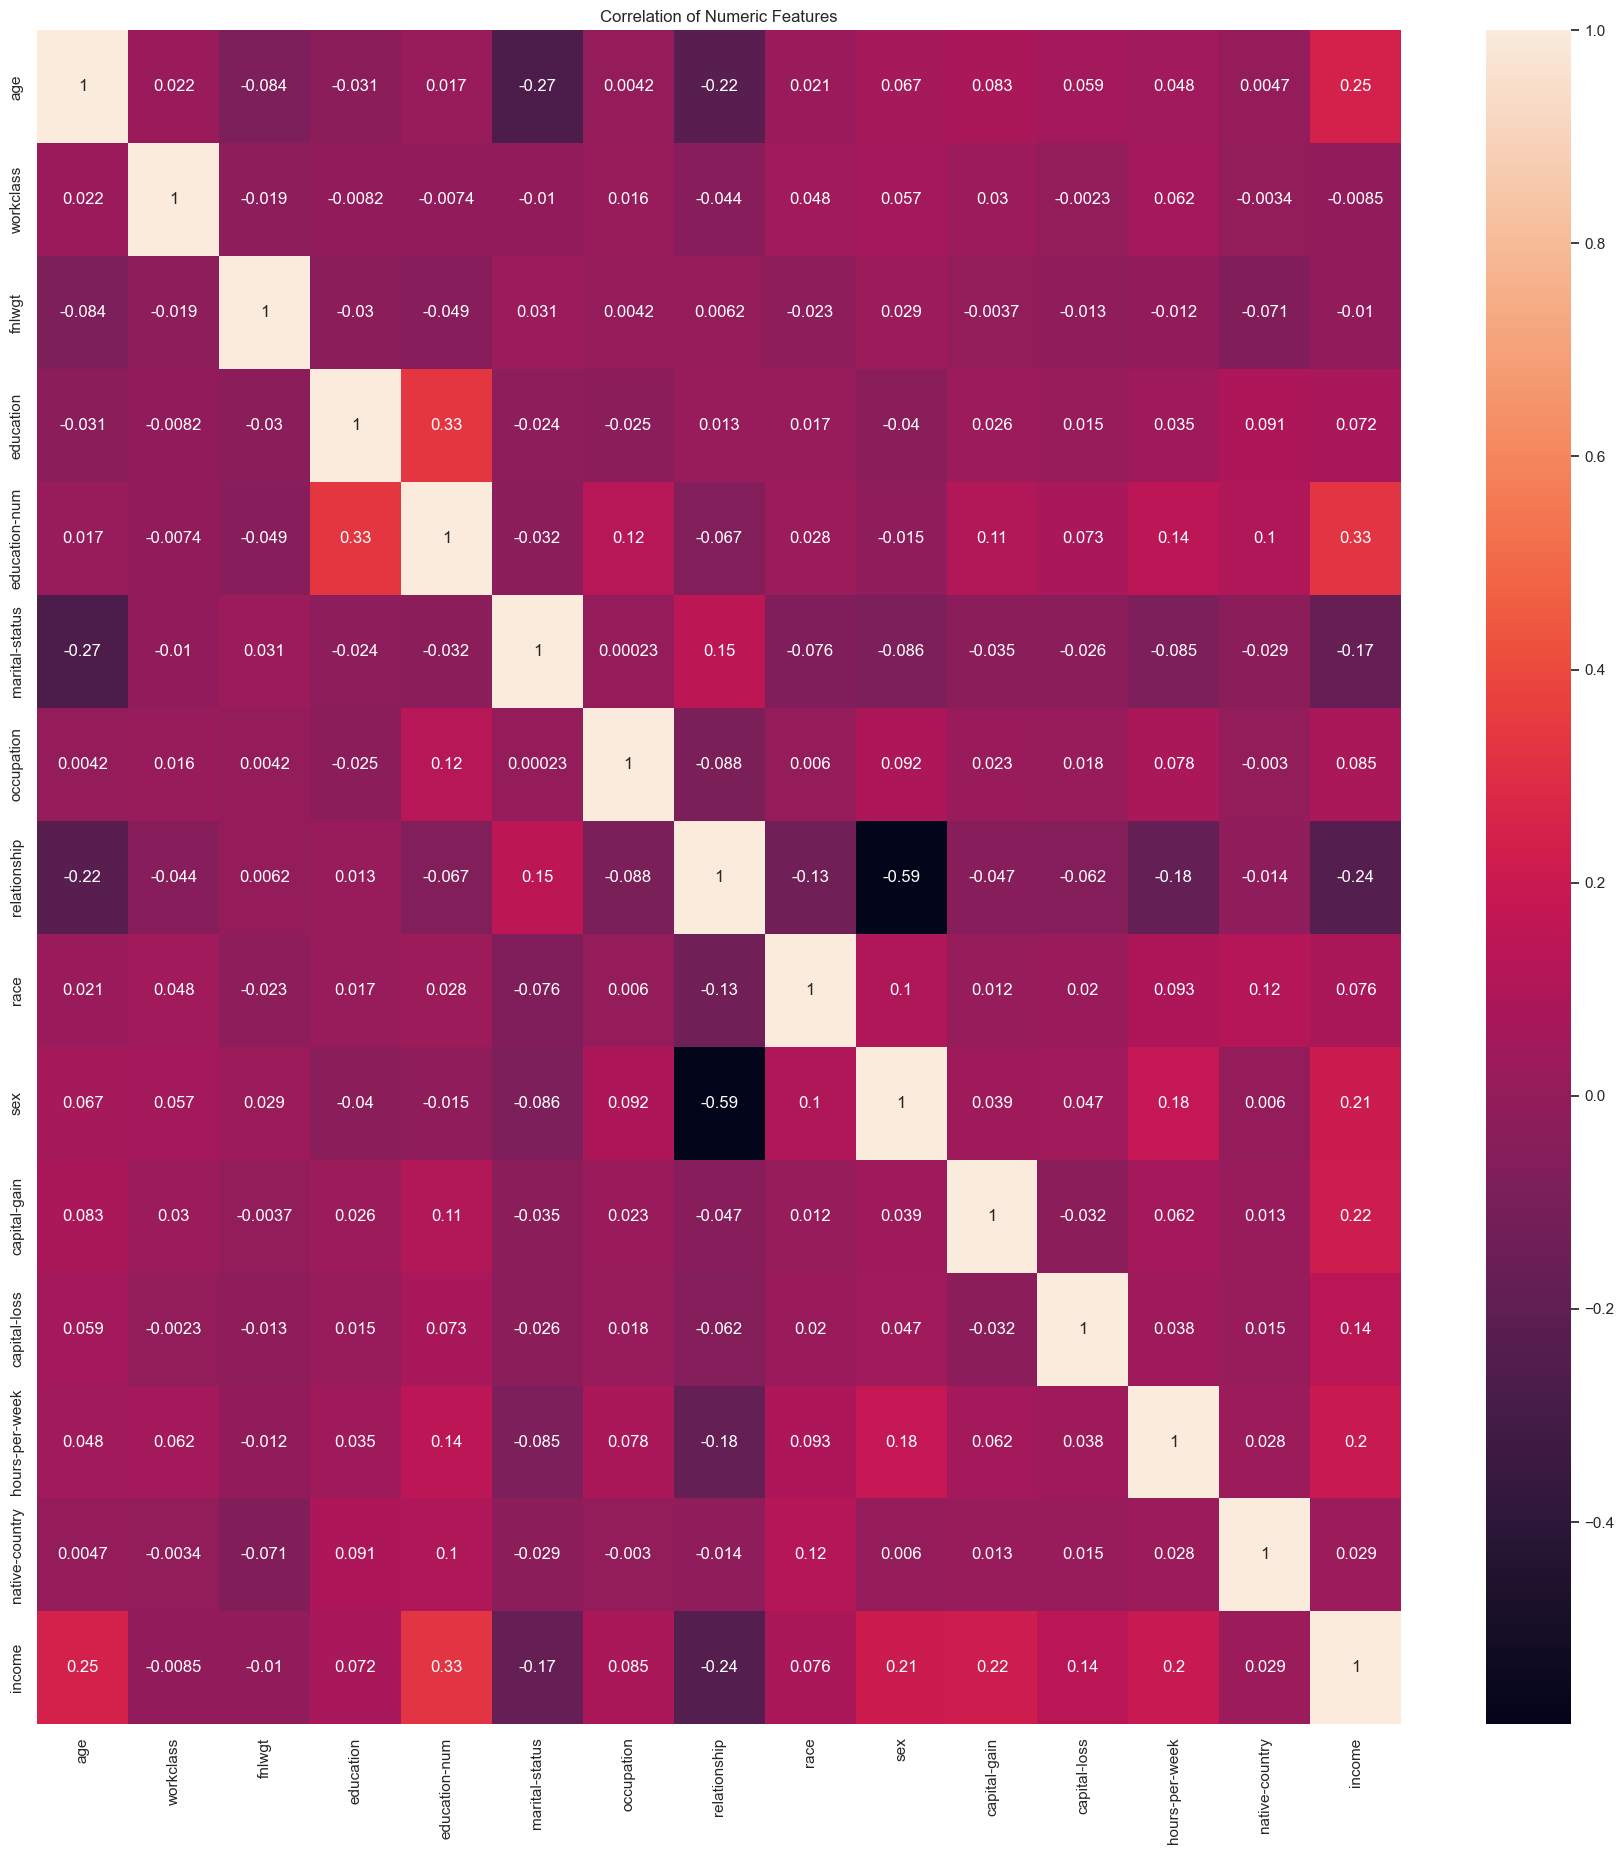

In [28]:
correlation_matrix = data_encoded.corr(method = 'pearson')

plt.figure(figsize=(22, 22))
sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation of Numeric Features')
plt.show()

The dependent variable income is mostly correlated with age, education-num, capital-gain and hours-per-week.

In [29]:
# Creating a pairplot of dataset
#sns.pairplot(data_encoded)
#plt.show()

## Feature selection

In [30]:
X = data_encoded.drop('income', axis=1)
Y = data_encoded['income']

In [31]:
selector = SelectKBest(chi2)
X_selected = selector.fit_transform(X, Y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['age', 'fnlwgt', 'education-num', 'marital-status', 'occupation',
       'relationship', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [32]:
# leaving features with the highest score

X = X.drop(['workclass', 'education', 'race',
            'fnlwgt', 'relationship', 'hours-per-week', 'capital-loss'], axis=1)

## Feature Scaling

In [33]:
#from sklearn.preprocessing import StandardScaler
#
#for col in X.columns:
#    scaler = StandardScaler()
#    X[col] = scaler.fit_transform(X[col].values.reshape(-1, 1))

## Fixing imbalanced dataset

In [34]:
Y.value_counts(normalize=True)

income
0    0.74488
1    0.25512
Name: proportion, dtype: float64

In [35]:
#from imblearn.over_sampling import RandomOverSampler
#ros = RandomOverSampler(random_state=42)
#ros.fit(X, Y)

In [36]:
#X_resampled, Y_resampled = ros.fit_resample(X, Y)
#Y_resampled.value_counts(normalize=True)

In [37]:
from imblearn.over_sampling import SMOTE

sm= SMOTE()
X_resampled, Y_resampled = sm.fit_resample(X, Y)
Y_resampled.value_counts(normalize=True)

income
0    0.5
1    0.5
Name: proportion, dtype: float64

## Creating a train test split

In [38]:
#df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['target'])
#df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['target'])

X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, Y_resampled, test_size=0.3, stratify=Y_resampled, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [39]:
# save datasets
X_train.to_csv('census_income_preprocessed/X_train.csv', index=False)
X_val.to_csv('census_income_preprocessed/X_validation.csv', index=False)
X_test.to_csv('census_income_preprocessed/X_test.csv', index=False)
y_train.to_csv('census_income_preprocessed/y_train.csv', index=False)
y_val.to_csv('census_income_preprocessed/y_validation.csv', index=False)

In [40]:
X_train.shape

(24542, 7)

In [41]:
X_train

,age,education-num,marital-status,occupation,sex,capital-gain,native-country
10303,37,9,0,6,1,0,38
18218,58,4,2,13,1,0,38
20944,46,7,0,9,1,0,38
1675,32,9,4,13,0,0,38
5079,56,7,0,11,0,0,38
...,...,...,...,...,...,...,...
24817,77,12,2,3,1,0,38
11395,58,7,2,2,1,0,38
30780,55,9,2,2,1,0,38
21037,29,10,4,9,0,0,38
